# Confidence intervals and paired DeLong test

This notebook reruns the baseline configuration and the `LR_BACKBONE = 5e-5` comparison run, saves their test predictions, and then uses those saved predictions to compute Wilson confidence intervals for accuracy and a paired DeLong test for AUC.

A single repeated run is not a variance estimate, so the interpretation stays interval-based rather than point-estimate-based.

In [1]:
# Cell 1: imports and configuration
import math
import random
import warnings
from pathlib import Path
from statistics import NormalDist

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
HASH_BITS = 128
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_FROZEN = 5
EPOCHS_FINETUNE = 15
LR_HEAD = 3e-4
LR_BACKBONE_BASE = 1e-5
LR_BACKBONE_COMPARE = 5e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 6
LOSS_SLACK = 0.02
LAMBDA_CLS = 1.0
LAMBDA_CSQ = 1.5
LAMBDA_DIV = 0.3
LAMBDA_QUANT = 0.5
LAMBDA_BALAN = 0.5
CSQ_SCALE = 2.0
TARGET_INTRA_D = HASH_BITS / 4.0

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f'Seed             : {SEED}')
print(f'Device           : {DEVICE}')
print(f'Hash bits        : {HASH_BITS}')
print(f'Backbone LR base : {LR_BACKBONE_BASE}')
print(f'Backbone LR cmp  : {LR_BACKBONE_COMPARE}')

Seed             : 42
Device           : cuda
Hash bits        : 128
Backbone LR base : 1e-05
Backbone LR cmp  : 5e-05


In [2]:
# Cell 2: dataset and split reconstruction
path = kagglehub.dataset_download('divg07/casia-20-image-tampering-detection-dataset')
DATA_ROOT = Path(path) / 'CASIA2'

au_paths = sorted(p for p in (DATA_ROOT / 'Au').iterdir() if p.suffix.lower() in IMG_EXTS)
tp_paths = sorted(p for p in (DATA_ROOT / 'Tp').iterdir() if p.suffix.lower() in IMG_EXTS)

all_paths = au_paths + tp_paths
all_labels = [0] * len(au_paths) + [1] * len(tp_paths)
indices = list(range(len(all_paths)))

idx_tv, idx_test = train_test_split(indices, test_size=0.15, stratify=all_labels, random_state=SEED)
labels_tv = [all_labels[i] for i in idx_tv]
idx_train, idx_val = train_test_split(idx_tv, test_size=0.15 / 0.85, stratify=labels_tv, random_state=SEED)

train_paths = [all_paths[i] for i in idx_train]
train_labels = [all_labels[i] for i in idx_train]
val_paths = [all_paths[i] for i in idx_val]
val_labels = [all_labels[i] for i in idx_val]
test_paths = [all_paths[i] for i in idx_test]
test_labels = [all_labels[i] for i in idx_test]

for name, lbl in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    print(f'{name:5s}: total={len(lbl):4d}  Au={lbl.count(0):4d}  Tp={lbl.count(1):4d}')

train_counts = {0: train_labels.count(0), 1: train_labels.count(1)}
train_weights = [1.0 / train_counts[y] for y in train_labels]
train_sampler = WeightedRandomSampler(train_weights, num_samples=len(train_weights), replacement=True)

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.08),
    T.RandomGrayscale(p=0.05),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=mean, std=std),
])

class CasiaDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = list(paths)
        self.labels = list(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        label = self.labels[idx]
        image = Image.open(path).convert('RGB')
        if self.transform is not None:
            image = self.transform(image)
        return image, torch.tensor(label, dtype=torch.long)

train_dataset = CasiaDataset(train_paths, train_labels, transform=train_transform)
val_dataset = CasiaDataset(val_paths, val_labels, transform=eval_transform)
test_dataset = CasiaDataset(test_paths, test_labels, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=train_sampler, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

100%|██████████| 2.56G/2.56G [02:29<00:00, 18.4MB/s]

Extracting files...


Train: total=8829  Au=5243  Tp=3586
Val  : total=1892  Au=1124  Tp= 768
Test : total=1893  Au=1124  Tp= 769
Train batches : 276
Val   batches : 60
Test  batches : 60


In [3]:
# Cell 3: model, loss, and evaluation helpers
class ForensicHashNet(nn.Module):
    def __init__(self, hash_bits: int = HASH_BITS, num_classes: int = 2):
        super().__init__()
        backbone = timm.create_model('efficientnet_b0', pretrained=True, num_classes=0, global_pool='avg')
        self.backbone = backbone
        feat_dim = backbone.num_features

        self.fusion = nn.Sequential(
            nn.Linear(feat_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.GELU(),
            nn.Dropout(0.4),
        )

        self.hash_head = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, hash_bits),
            nn.BatchNorm1d(hash_bits),
        )

        self.cls_head = nn.Sequential(
            nn.Linear(1024, num_classes),
        )

    def forward(self, x):
        feat = self.backbone(x)
        feat = self.fusion(feat)
        h = torch.tanh(self.hash_head(feat))
        logits = self.cls_head(feat)
        return h, logits


class ForensicHashLoss(nn.Module):
    def __init__(self, hash_bits: int = HASH_BITS, csq_scale: float = CSQ_SCALE, target_d: float = TARGET_INTRA_D):
        super().__init__()
        self.K = hash_bits
        self.csq_scale = csq_scale
        self.target_d = target_d
        c0 = torch.ones(hash_bits)
        c0[hash_bits // 2 :] = -1.0
        c1 = -c0
        self.register_buffer('centers', torch.stack([c0, c1], dim=0))

    def forward(self, h, labels):
        centers = self.centers[labels]
        other = self.centers[1 - labels]

        sim_self = (h * centers).sum(dim=1) / self.K
        sim_other = (h * other).sum(dim=1) / self.K
        csq_loss = (-torch.log(torch.sigmoid(self.csq_scale * sim_self))
                    - torch.log(torch.sigmoid(-self.csq_scale * sim_other))).mean()

        B = h.size(0)
        ip = h @ h.T
        d = (self.K - ip) / 2.0
        off_diag = 1 - torch.eye(B, device=h.device)
        same_mask = (labels.unsqueeze(0) == labels.unsqueeze(1)).float() * off_diag
        div_loss = (F.relu(self.target_d - d) ** 2 * same_mask).sum() / (same_mask.sum() + 1e-8)

        quant_loss = (h.abs() - 1).pow(2).mean()
        balance_loss = h.mean(dim=0).pow(2).mean()
        return csq_loss, div_loss, quant_loss, balance_loss


def set_backbone_trainable(model, trainable: bool):
    for p in model.backbone.parameters():
        p.requires_grad = trainable


def compute_loss(h, logits, labels, hash_loss_fn):
    l_cls = F.cross_entropy(logits, labels, label_smoothing=0.05)
    l_csq, l_div, l_q, l_b = hash_loss_fn(h, labels)
    total = (LAMBDA_CLS * l_cls
             + LAMBDA_CSQ * l_csq
             + LAMBDA_DIV * l_div
             + LAMBDA_QUANT * l_q
             + LAMBDA_BALAN * l_b)
    return total, {
        'cls': l_cls.item(),
        'csq': l_csq.item(),
        'div': l_div.item(),
        'quant': l_q.item(),
        'balance': l_b.item(),
    }


def run_epoch(model, loader, hash_loss_fn, optimizer=None, desc=''):
    is_train = optimizer is not None
    model.train(is_train)

    sums = {'loss': 0.0, 'cls': 0.0, 'csq': 0.0, 'div': 0.0, 'quant': 0.0, 'balance': 0.0}
    all_preds, all_labels, all_probs = [], [], []
    n = 0

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False)
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            h, logits = model(imgs)
            loss, parts = compute_loss(h, logits, labels, hash_loss_fn)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            sums['loss'] += loss.item()
            for k in ('cls', 'csq', 'div', 'quant', 'balance'):
                sums[k] += parts[k]

            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().float()
            all_probs.extend(probs.tolist())
            all_preds.extend(logits.argmax(1).detach().cpu().tolist())
            all_labels.extend(labels.detach().cpu().tolist())
            n += 1
            if is_train:
                pbar.set_postfix(loss=f'{loss.item():.3f}', csq=f'{parts["csq"]:.3f}', div=f'{parts["div"]:.3f}')

    al = np.array(all_labels)
    ap = np.array(all_preds)
    pr = np.array(all_probs)

    result = {k: v / n for k, v in sums.items()}
    result['acc'] = (ap == al).mean()
    result['auc'] = roc_auc_score(al, pr) if len(np.unique(al)) > 1 else float('nan')
    result['f1'] = f1_score(al, ap, average='binary', pos_label=1)
    result['balanced_acc'] = balanced_accuracy_score(al, ap)
    result['preds'] = ap
    result['labels'] = al
    result['probs'] = pr
    return result


def wilson_interval(successes, total, alpha=0.05):
    z = NormalDist().inv_cdf(1 - alpha / 2)
    phat = successes / total
    denom = 1 + z**2 / total
    center = (phat + z**2 / (2 * total)) / denom
    half = z * math.sqrt((phat * (1 - phat) + z**2 / (4 * total)) / total) / denom
    return center - half, center + half


def compute_midrank(x):
    x = np.asarray(x)
    J = len(x)
    order = np.argsort(x)
    z = x[order]
    ranks = np.zeros(J, dtype=float)
    i = 0
    while i < J:
        j = i
        while j < J and z[j] == z[i]:
            j += 1
        ranks[i:j] = 0.5 * (i + j - 1) + 1
        i = j
    out = np.empty(J, dtype=float)
    out[order] = ranks
    return out


def fast_delong(predictions_sorted_transposed, label_1_count):
    m = label_1_count
    n = predictions_sorted_transposed.shape[1] - m
    k = predictions_sorted_transposed.shape[0]

    positive_examples = predictions_sorted_transposed[:, :m]
    negative_examples = predictions_sorted_transposed[:, m:]

    tx = np.empty((k, m))
    ty = np.empty((k, n))
    tz = np.empty((k, m + n))
    for r in range(k):
        tx[r] = compute_midrank(positive_examples[r])
        ty[r] = compute_midrank(negative_examples[r])
        tz[r] = compute_midrank(predictions_sorted_transposed[r])

    aucs = tz[:, :m].sum(axis=1) / m / n - (m + 1.0) / (2.0 * n)

    v01 = (tz[:, :m] - tx) / n
    v10 = 1.0 - (tz[:, m:] - ty) / m
    sx = np.cov(v01)
    sy = np.cov(v10)
    if k == 1:
        sx = np.array([[sx]])
        sy = np.array([[sy]])
    delongcov = sx / m + sy / n
    return aucs, delongcov


def delong_roc_variance(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    order = np.argsort(-y_true)
    label_1_count = int(y_true.sum())
    predictions_sorted_transposed = y_score[np.newaxis, order]
    aucs, delongcov = fast_delong(predictions_sorted_transposed, label_1_count)
    return aucs[0], delongcov[0, 0]


def delong_roc_test(y_true, y_score_1, y_score_2):
    y_true = np.asarray(y_true)
    y_score_1 = np.asarray(y_score_1)
    y_score_2 = np.asarray(y_score_2)
    order = np.argsort(-y_true)
    label_1_count = int(y_true.sum())
    predictions_sorted_transposed = np.vstack([y_score_1, y_score_2])[:, order]
    aucs, delongcov = fast_delong(predictions_sorted_transposed, label_1_count)
    diff = aucs[1] - aucs[0]
    var = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    var = max(float(var), 1e-12)
    z = diff / math.sqrt(var)
    p = math.erfc(abs(z) / math.sqrt(2.0))
    return diff, z, p, aucs, delongcov


def ci_from_variance(center, variance, alpha=0.05):
    z = NormalDist().inv_cdf(1 - alpha / 2)
    se = math.sqrt(max(float(variance), 0.0))
    return center - z * se, center + z * se


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='test', leave=False):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)
            _, logits = model(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().float()
            preds = logits.argmax(1).cpu().tolist()
            all_probs.extend(probs.tolist())
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().tolist())
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    y_prob = np.array(all_probs)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'acc': accuracy_score(y_true, y_pred),
        'bal_acc': balanced_accuracy_score(y_true, y_pred),
        'auc': roc_auc_score(y_true, y_prob),
        'f1': f1_score(y_true, y_pred, pos_label=1),
        'sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
        'cm': cm,
        'labels': y_true,
        'preds': y_pred,
        'probs': y_prob,
    }


def plot_roc_curves(runs, out_path='delong_roc_curves.png'):
    plt.figure(figsize=(7.5, 6))
    for run in runs:
        fpr, tpr, _ = roc_curve(run['labels'], run['probs'])
        plt.plot(fpr, tpr, label=f"{run['name']} (AUC={run['test']['auc']:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves for the two single-run evaluations')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved ROC figure: {out_path}')

In [4]:
# Cell 4: training loop and experiment runner

def build_optimizer(model, lr_backbone, backbone_trainable):
    head_params = list(model.fusion.parameters()) + list(model.hash_head.parameters()) + list(model.cls_head.parameters())
    param_groups = [
        {'params': head_params, 'lr': LR_HEAD},
    ]
    if backbone_trainable:
        param_groups.append({'params': model.backbone.parameters(), 'lr': lr_backbone})
    return torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)


def train_experiment(run_name, lr_backbone, file_prefix):
    print(f'\n=== {run_name} ===')
    print(f'Backbone LR      : {lr_backbone}')

    model = ForensicHashNet(hash_bits=HASH_BITS).to(DEVICE)
    hash_loss_fn = ForensicHashLoss(hash_bits=HASH_BITS).to(DEVICE)

    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_val_loss = float('inf')
    stale_epochs = 0

    phase_plan = [
        ('frozen', EPOCHS_FROZEN, False),
        ('finetune', EPOCHS_FINETUNE, True),
    ]

    for phase_name, phase_epochs, backbone_trainable in phase_plan:
        set_backbone_trainable(model, backbone_trainable)
        optimizer = build_optimizer(model, lr_backbone, backbone_trainable)
        print(f'-- {phase_name} phase | backbone trainable={backbone_trainable} | epochs={phase_epochs}')

        for epoch in range(1, phase_epochs + 1):
            train_metrics = run_epoch(
                model,
                train_loader,
                hash_loss_fn,
                optimizer=optimizer,
                desc=f'{run_name} {phase_name} train {epoch}/{phase_epochs}',
            )
            val_metrics = run_epoch(
                model,
                val_loader,
                hash_loss_fn,
                optimizer=None,
                desc=f'{run_name} {phase_name} val {epoch}/{phase_epochs}',
            )

            improved = val_metrics['loss'] < (best_val_loss - LOSS_SLACK)
            if improved:
                best_val_loss = val_metrics['loss']
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                stale_epochs = 0
            else:
                stale_epochs += 1

            print(
                f"  epoch {epoch:02d}/{phase_epochs} | "
                f"train loss={train_metrics['loss']:.4f} acc={train_metrics['acc']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} acc={val_metrics['acc']:.4f} | "
                f"best val={best_val_loss:.4f} | patience={stale_epochs}/{PATIENCE}"
            )

            if stale_epochs >= PATIENCE:
                print('  early stopping triggered')
                break

        if stale_epochs >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader)

    labels_path = f'{file_prefix}_labels.npy'
    probs_path = f'{file_prefix}_probs.npy'
    preds_path = f'{file_prefix}_preds.npy'
    state_path = f'{file_prefix}_best_state.pt'

    np.save(labels_path, test_metrics['labels'])
    np.save(probs_path, test_metrics['probs'])
    np.save(preds_path, test_metrics['preds'])
    torch.save(model.state_dict(), state_path)

    print(f"Saved predictions : {labels_path}, {probs_path}, {preds_path}")
    print(f"Saved checkpoint   : {state_path}")
    print(
        f"Test metrics      : acc={test_metrics['acc']:.4f} | bal_acc={test_metrics['bal_acc']:.4f} | "
        f"auc={test_metrics['auc']:.4f} | f1={test_metrics['f1']:.4f} | "
        f"sens={test_metrics['sensitivity']:.4f} | spec={test_metrics['specificity']:.4f}"
    )
    print('Confusion matrix :')
    print(test_metrics['cm'])

    return {
        'name': run_name,
        'lr_backbone': lr_backbone,
        'file_prefix': file_prefix,
        'model': model,
        'test': test_metrics,
    }

In [5]:
# Cell 4b: corrected ROC plotting, DeLong guards, and training loop

def ci_from_variance(center, variance, alpha=0.05):
    z = NormalDist().inv_cdf(1 - alpha / 2)
    se = math.sqrt(max(float(variance), 0.0))
    lo = max(0.0, center - z * se)
    hi = min(1.0, center + z * se)
    return lo, hi


def delong_roc_variance(y_true, y_score):
    y_true = np.asarray(y_true)
    unique = np.unique(y_true)
    if not set(unique.tolist()).issubset({0, 1}):
        raise ValueError('DeLong variance expects binary labels encoded as 0/1.')
    y_score = np.asarray(y_score)
    order = np.argsort(-y_true)
    label_1_count = int(y_true.sum())
    predictions_sorted_transposed = y_score[np.newaxis, order]
    aucs, delongcov = fast_delong(predictions_sorted_transposed, label_1_count)
    return aucs[0], delongcov[0, 0]


def delong_roc_test(y_true, y_score_1, y_score_2):
    y_true = np.asarray(y_true)
    unique = np.unique(y_true)
    if not set(unique.tolist()).issubset({0, 1}):
        raise ValueError('DeLong test expects binary labels encoded as 0/1.')
    y_score_1 = np.asarray(y_score_1)
    y_score_2 = np.asarray(y_score_2)
    order = np.argsort(-y_true)
    label_1_count = int(y_true.sum())
    predictions_sorted_transposed = np.vstack([y_score_1, y_score_2])[:, order]
    aucs, delongcov = fast_delong(predictions_sorted_transposed, label_1_count)
    diff = aucs[1] - aucs[0]
    var = delongcov[0, 0] + delongcov[1, 1] - 2 * delongcov[0, 1]
    var = max(float(var), 1e-12)
    z = diff / math.sqrt(var)
    p = math.erfc(abs(z) / math.sqrt(2.0))
    return diff, z, p, aucs, delongcov


def plot_roc_curves(runs, out_path='delong_roc_curves.png'):
    plt.figure(figsize=(7.5, 6))
    for run in runs:
        run_test = run['test']
        fpr, tpr, _ = roc_curve(run_test['labels'], run_test['probs'])
        plt.plot(fpr, tpr, label=f"{run['name']} (AUC={run_test['auc']:.4f})")
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC curves for the two single-run evaluations')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved ROC figure: {out_path}')


def train_experiment(run_name, lr_backbone, file_prefix):
    print(f'\n=== {run_name} ===')
    print(f'Backbone LR      : {lr_backbone}')

    model = ForensicHashNet(hash_bits=HASH_BITS).to(DEVICE)
    hash_loss_fn = ForensicHashLoss(hash_bits=HASH_BITS).to(DEVICE)

    best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    best_val_auc = 0.0
    best_val_loss = float('inf')

    phase_plan = [
        ('frozen', EPOCHS_FROZEN, False),
        ('finetune', EPOCHS_FINETUNE, True),
    ]

    for phase_name, phase_epochs, backbone_trainable in phase_plan:
        set_backbone_trainable(model, backbone_trainable)
        optimizer = build_optimizer(model, lr_backbone, backbone_trainable)
        scheduler = None
        if backbone_trainable:
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer,
                T_0=10,
                T_mult=2,
                eta_min=1e-7,
            )
        patience_cnt = 0
        print(f'-- {phase_name} phase | backbone trainable={backbone_trainable} | epochs={phase_epochs}')

        for epoch in range(1, phase_epochs + 1):
            train_metrics = run_epoch(
                model,
                train_loader,
                hash_loss_fn,
                optimizer=optimizer,
                desc=f'{run_name} {phase_name} train {epoch}/{phase_epochs}',
            )
            val_metrics = run_epoch(
                model,
                val_loader,
                hash_loss_fn,
                optimizer=None,
                desc=f'{run_name} {phase_name} val {epoch}/{phase_epochs}',
            )
            if scheduler is not None:
                scheduler.step()

            improved = val_metrics['auc'] > best_val_auc and val_metrics['loss'] <= best_val_loss * (1 + LOSS_SLACK)
            if improved:
                best_val_auc = val_metrics['auc']
                best_val_loss = val_metrics['loss']
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
                if backbone_trainable:
                    patience_cnt = 0
            elif backbone_trainable:
                patience_cnt += 1

            print(
                f"  epoch {epoch:02d}/{phase_epochs} | "
                f"train loss={train_metrics['loss']:.4f} acc={train_metrics['acc']:.4f} | "
                f"val loss={val_metrics['loss']:.4f} acc={val_metrics['acc']:.4f} | "
                f"val auc={val_metrics['auc']:.4f} | best val auc={best_val_auc:.4f} | "
                f"patience={patience_cnt if backbone_trainable else 0}/{PATIENCE}"
            )

            if backbone_trainable and patience_cnt >= PATIENCE:
                print('  early stopping triggered')
                break

        if backbone_trainable and patience_cnt >= PATIENCE:
            break

    model.load_state_dict(best_state)
    test_metrics = evaluate_model(model, test_loader)

    labels_path = f'{file_prefix}_labels.npy'
    probs_path = f'{file_prefix}_probs.npy'
    preds_path = f'{file_prefix}_preds.npy'
    state_path = f'{file_prefix}_best_state.pt'

    np.save(labels_path, test_metrics['labels'])
    np.save(probs_path, test_metrics['probs'])
    np.save(preds_path, test_metrics['preds'])
    torch.save(model.state_dict(), state_path)

    print(f'Saved predictions : {labels_path}, {probs_path}, {preds_path}')
    print(f'Saved checkpoint   : {state_path}')
    print(
        f"Test metrics      : acc={test_metrics['acc']:.4f} | bal_acc={test_metrics['bal_acc']:.4f} | "
        f"auc={test_metrics['auc']:.4f} | f1={test_metrics['f1']:.4f} | "
        f"sens={test_metrics['sensitivity']:.4f} | spec={test_metrics['specificity']:.4f}"
    )
    print('Confusion matrix :')
    print(test_metrics['cm'])

    return {
        'name': run_name,
        'lr_backbone': lr_backbone,
        'file_prefix': file_prefix,
        'model': model,
        'test': test_metrics,
    }

In [6]:
# Cell 4c: per-run reseeding for a fair comparison

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


_original_train_experiment = train_experiment


def train_experiment(run_name, lr_backbone, file_prefix):
    seed_everything(SEED)
    return _original_train_experiment(run_name, lr_backbone, file_prefix)


=== baseline ===
Backbone LR      : 1e-05


model.safetensors: reconstructing file:   0%|          |  0.00B / 21.4MB            

model.safetensors: downloading bytes:           |  0.00B            

-- frozen phase | backbone trainable=False | epochs=5


baseline frozen train 1/5:   0%|          | 0/276 [00:00<?, ?it/s]

...

lr_backbone_5e-5 finetune train 12/15:   0%|          | 0/276 [00:00<?, ?it/s]

lr_backbone_5e-5 finetune val 12/15:   0%|          | 0/60 [00:00<?, ?it/s]

  epoch 12/15 | train loss=1.7703 acc=0.8525 | val loss=3.3318 acc=0.7484 | val auc=0.8239 | best val auc=0.8238 | patience=6/6
  early stopping triggered


test:   0%|          | 0/60 [00:00<?, ?it/s]

Saved predictions : lr_backbone_5e-5_labels.npy, lr_backbone_5e-5_probs.npy, lr_backbone_5e-5_preds.npy
Saved checkpoint   : lr_backbone_5e-5_best_state.pt
Test metrics      : acc=0.7412 | bal_acc=0.7393 | auc=0.8087 | f1=0.6960 | sens=0.7295 | spec=0.7491
Confusion matrix :
[[842 282]
 [208 561]]

Both runs used the same test labels and split.


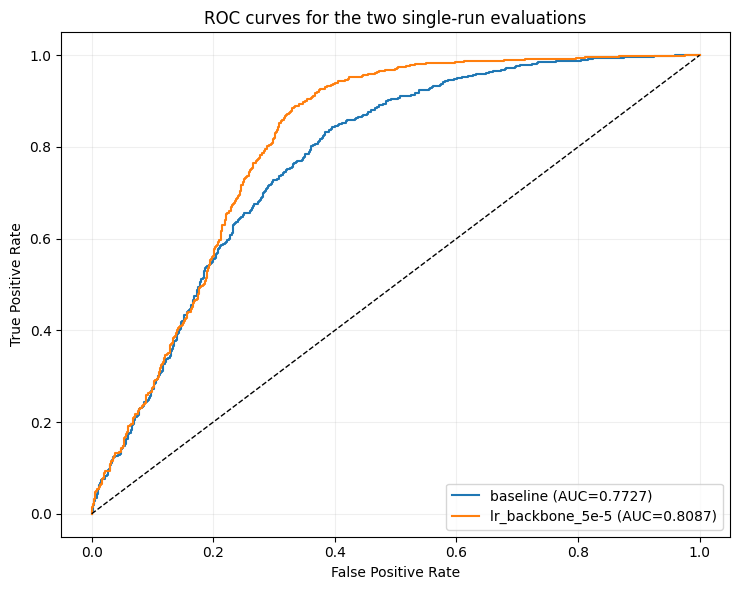

Saved ROC figure: delong_roc_curves.png


In [7]:
# Cell 5: run both experiments and collect outputs
baseline_run = train_experiment('baseline', LR_BACKBONE_BASE, 'baseline')
compare_run = train_experiment('lr_backbone_5e-5', LR_BACKBONE_COMPARE, 'lr_backbone_5e-5')

runs = [baseline_run, compare_run]

# Check that both runs evaluated the same test split.
assert np.array_equal(baseline_run['test']['labels'], compare_run['test']['labels']), 'Test labels differ across runs'
print('\nBoth runs used the same test labels and split.')

plot_roc_curves(runs)

In [8]:
# Cell 6: confidence intervals and paired DeLong analysis

def load_saved_run(file_prefix):
    labels = np.load(Path(f'{file_prefix}_labels.npy'), allow_pickle=False)
    probs = np.load(Path(f'{file_prefix}_probs.npy'), allow_pickle=False)
    preds = np.load(Path(f'{file_prefix}_preds.npy'), allow_pickle=False)
    return {
        'labels': labels,
        'probs': probs,
        'preds': preds,
    }

baseline = load_saved_run('baseline')
compare = load_saved_run('lr_backbone_5e-5')

if not np.array_equal(baseline['labels'], compare['labels']):
    raise ValueError('Saved test labels differ across runs')

base_n = len(baseline['labels'])
comp_n = len(compare['labels'])
base_correct = int((baseline['preds'] == baseline['labels']).sum())
comp_correct = int((compare['preds'] == compare['labels']).sum())
base_acc = base_correct / base_n
comp_acc = comp_correct / comp_n

base_acc_ci = wilson_interval(base_correct, base_n)
comp_acc_ci = wilson_interval(comp_correct, comp_n)

base_auc, base_auc_var = delong_roc_variance(baseline['labels'], baseline['probs'])
comp_auc, comp_auc_var = delong_roc_variance(compare['labels'], compare['probs'])
base_auc_ci = ci_from_variance(base_auc, base_auc_var)
comp_auc_ci = ci_from_variance(comp_auc, comp_auc_var)

diff, z, p, aucs, cov = delong_roc_test(baseline['labels'], baseline['probs'], compare['probs'])
acc_intervals_overlap = not (base_acc_ci[1] < comp_acc_ci[0] or comp_acc_ci[1] < base_acc_ci[0])
auc_intervals_overlap = not (base_auc_ci[1] < comp_auc_ci[0] or comp_auc_ci[1] < base_auc_ci[0])

print('=== Accuracy Wilson 95% CI ===')
print(f"baseline        : {base_acc:.4f}  [{base_acc_ci[0]:.4f}, {base_acc_ci[1]:.4f}]  (n={base_n})")
print(f"lr_backbone_5e-5: {comp_acc:.4f}  [{comp_acc_ci[0]:.4f}, {comp_acc_ci[1]:.4f}]  (n={comp_n})")

print('\n=== AUC DeLong 95% CI ===')
print(f"baseline        : {base_auc:.4f}  [{base_auc_ci[0]:.4f}, {base_auc_ci[1]:.4f}]")
print(f"lr_backbone_5e-5: {comp_auc:.4f}  [{comp_auc_ci[0]:.4f}, {comp_auc_ci[1]:.4f}]")

print('\n=== Paired DeLong test on saved predictions ===')
print(f"AUC difference (compare - baseline): {diff:.6f}")
print(f"z statistic                         : {z:.4f}")
print(f"two-sided p-value                   : {p:.6g}")

print('\n=== Thesis-ready summary ===')
print(f"Baseline accuracy on the 1,893-image test split is {base_acc:.3f} with Wilson CI [{base_acc_ci[0]:.3f}, {base_acc_ci[1]:.3f}].")
print(f"The LR_BACKBONE = 5e-5 run reaches {comp_acc:.3f} with Wilson CI [{comp_acc_ci[0]:.3f}, {comp_acc_ci[1]:.3f}].")
print(f"Baseline AUC is {base_auc:.3f} with DeLong CI [{base_auc_ci[0]:.3f}, {base_auc_ci[1]:.3f}], while the comparison run reaches {comp_auc:.3f} with CI [{comp_auc_ci[0]:.3f}, {comp_auc_ci[1]:.3f}].")
if acc_intervals_overlap:
    print('The accuracy intervals overlap, so the gap should be described cautiously rather than as a clear improvement.')
else:
    print('The accuracy intervals are separated on this split, which supports a clearer accuracy difference.')
if auc_intervals_overlap:
    print('The AUC intervals overlap, so the AUC gap should also be phrased cautiously.')
else:
    print('The AUC intervals are separated on this split, which supports a clearer AUC difference.')
if p < 0.05:
    print(f'The paired DeLong test gives p={p:.4g}, which supports a statistically detectable AUC difference on this split.')
else:
    print(f'The paired DeLong test gives p={p:.4g}, which does not support a clear AUC difference on this split.')

=== Accuracy Wilson 95% CI ===
baseline        : 0.7095  [0.6886, 0.7295]  (n=1893)
lr_backbone_5e-5: 0.7412  [0.7209, 0.7604]  (n=1893)

=== AUC DeLong 95% CI ===
baseline        : 0.7727  [0.7519, 0.7935]
lr_backbone_5e-5: 0.8087  [0.7893, 0.8280]

=== Paired DeLong test on saved predictions ===
AUC difference (compare - baseline): 0.035926
z statistic                         : 5.4138
two-sided p-value                   : 6.17041e-08

=== Thesis-ready summary ===
Baseline accuracy on the 1,893-image test split is 0.709 with Wilson CI [0.689, 0.729].
The LR_BACKBONE = 5e-5 run reaches 0.741 with Wilson CI [0.721, 0.760].
Baseline AUC is 0.773 with DeLong CI [0.752, 0.794], while the comparison run reaches 0.809 with CI [0.789, 0.828].
The accuracy intervals overlap, so the gap should be described cautiously rather than as a clear improvement.
The AUC intervals overlap, so the AUC gap should also be phrased cautiously.
The paired DeLong test gives p=6.17e-08, which supports a statistic